В цьому наборі завдань закріпимо те, що було на лекції з Computer Vision.

# Computer Vision with PyTorch Excercises. Solution


## 1. Наведіть 3 галузі промисловості, де комп'ютерний зір використовується сьогодні (можна згадати з лекції, або провести міні-рісерч).

Медицина (радіологія та діагностика)

Автоматичний аналіз МРТ, КТ, рентген-знімків.

Виявлення пухлин, кровотеч, переломів, діабетичної ретинопатії на знімках очного дна.

Це допомагає лікарям швидше та точніше ставити діагноз і зменшує ризик людської помилки.

Автомобільна промисловість та автономний транспорт

Системи допомоги водію (ADAS): виявлення пішоходів, знаків, розмітки смуг, інших авто.

Автопілот у Tesla, Waymo тощо працює саме на комп’ютерному зорі + сенсорах.

Це підвищує безпеку руху та автоматизує керування.

Рітейл та e-commerce

Розпізнавання товарів на полицях (інвентаризація, контроль наявності товару).

Візуальний пошук: «завантаж фото» → знайди схожий товар у каталозі.

Відеоаналітика в магазинах: підрахунок людей, аналіз черг, поведінки покупця.

## 2. Виділіть 20 хвилин аби ознайомитись та переглянути сайт [CNN Explainer](https://poloclub.github.io/cnn-explainer/).

* Завантажте власне будь-яке зображення за допомогою кнопки Upload" на сайті та подивіться, що відбувається на кожному шарі CNN, коли ваше зображення проходить через нього.

Напишіть 3 пункти, що ви дізнались після цієї вправи?

Як працює згортка (convolution)

Невеликий фільтр (kernel) «ковзає» по зображенню і на кожному кроці обчислює зважену суму пікселів.

Результат складає карту ознак (feature map), де підсвічуються певні патерни (наприклад, краї, кути, текстури).

Що роблять кілька шарів згорток

Перші шари вчаться знаходити прості ознаки: вертикальні/горизонтальні лінії, контури.

Глибші шари комбінують ці прості ознаки в більш складні — очі, ніс, частини об’єктів, а потім цілі об’єкти.

Тобто мережа будує ієрархію представлень: від «пікселів» до «сенсу».

Роль pooling та fully connected шарів

MaxPooling зменшує просторовий розмір карти ознак, залишаючи найважливіші активації → модель стає менш чутливою до зсувів і шуму.

Після кількох згорткових шарів fully connected шар перетворює ці ознаки у ймовірності класів (класифікація).

На CNN Explainer видно, як на кожному кроці змінюється зображення та активуються різні фільтри.

## 3. Завантажте навчальні та тестові набори даних [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST).

MNIST - базовий набір даних для задач Computer Vision. Часто використовується для навчання.

- Виведіть, скільки елементів в кожному наборі.
- Покажіть формат (розмірності) кожної картинки.
- Виведіть, які класи представлені в цьому наборі даних.

In [1]:
import torch
from torchvision import datasets, transforms

# Трансформація: перетворюємо зображення у тензор
transform = transforms.ToTensor()

# Завантаження MNIST
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# 1. Кількість елементів у кожному наборі
print("Розмір тренувального набору:", len(train_dataset))
print("Розмір тестового набору:", len(test_dataset))

# 2. Формат (розмірність) картинки
sample_img, sample_label = train_dataset[0]
print("Формат однієї картинки:", sample_img.shape)

# 3. Унікальні класи
classes = set()
for _, label in train_dataset:
    classes.add(label)

print("Класи у MNIST:", classes)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.79MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.79MB/s]


Розмір тренувального набору: 60000
Розмір тестового набору: 10000
Формат однієї картинки: torch.Size([1, 28, 28])
Класи у MNIST: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


## 4. Візуалізуйте щонайменше 5 різних зразків з навчального набору даних MNIST.

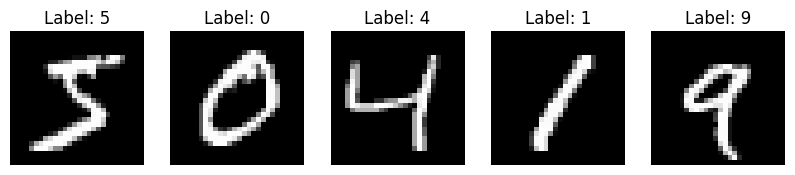

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))

for i in range(5):
    img, label = train_dataset[i]
    plt.subplot(1, 5, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.show()

## 5. Перетворіть навчальні та тестові набори даних MNIST у data loaders за допомогою `torch.utils.data.DataLoader`, встановіть `batch_size=32`.
- Покажіть, яку форму даних вертають дата лоадери.

In [3]:
from torch.utils.data import DataLoader

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Перевіряємо форму даних
images, labels = next(iter(train_loader))

print("Форма batch зображень:", images.shape)
print("Форма batch міток:", labels.shape)

Форма batch зображень: torch.Size([32, 1, 28, 28])
Форма batch міток: torch.Size([32])


## 6. Відтворіть `ModelV2`, яку ми розглядали на лекції
Це до слова та сама модель з [сайту CNN Explainer](https://poloclub.github.io/cnn-explainer/), також відома як TinyVGG і вона здатна навчатися на наборі даних MNIST.

Напишіть клас моделі.

In [4]:
import torch
import torch.nn as nn

class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # 28→14
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # 14→7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 10)   # 10 класів (0–9)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

model = ModelV2()
model

ModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=10, bias=True)
  )
)

## 7. Навчіть модель, яку ви побудували в попередній вправі, протягом 5 епох на CPU та GPU і подивіться, скільки часу це займе в кожному з варіантів.

In [5]:
import time
import torch.nn.functional as F

# Пристрій
device_cpu = torch.device("cpu")
device_gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU available:", torch.cuda.is_available())

# Функція навчання
def train_model(model, train_loader, device, epochs=5):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    model.train()
    start = time.time()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} | loss={epoch_loss:.4f} | acc={epoch_acc:.4f}")

    end = time.time()
    elapsed = end - start
    return model, elapsed

# 🔸 Навчання на CPU
model_cpu = ModelV2()           # новий екземпляр
model_cpu, time_cpu = train_model(model_cpu, train_loader, device_cpu, epochs=5)
print(f"\nЧас навчання на CPU: {time_cpu:.2f} сек")

# 🔸 Навчання на GPU (якщо є)
if torch.cuda.is_available():
    model_gpu = ModelV2()       # новий екземпляр
    model_gpu, time_gpu = train_model(model_gpu, train_loader, device_gpu, epochs=5)
    print(f"\nЧас навчання на GPU: {time_gpu:.2f} сек")
else:
    print("\nGPU недоступний у цьому середовищі, тому тренуємо лише на CPU.")
    model_gpu = None

GPU available: False
Epoch 1/5 | loss=0.1598 | acc=0.9497
Epoch 2/5 | loss=0.0466 | acc=0.9855
Epoch 3/5 | loss=0.0344 | acc=0.9891
Epoch 4/5 | loss=0.0280 | acc=0.9909
Epoch 5/5 | loss=0.0223 | acc=0.9931

Час навчання на CPU: 356.07 сек

GPU недоступний у цьому середовищі, тому тренуємо лише на CPU.


## 8. Зробіть прогнози за допомогою вашої навченої моделі та візуалізуйте принаймні 5 з них, порівнюючи прогноз з цільовою міткою.

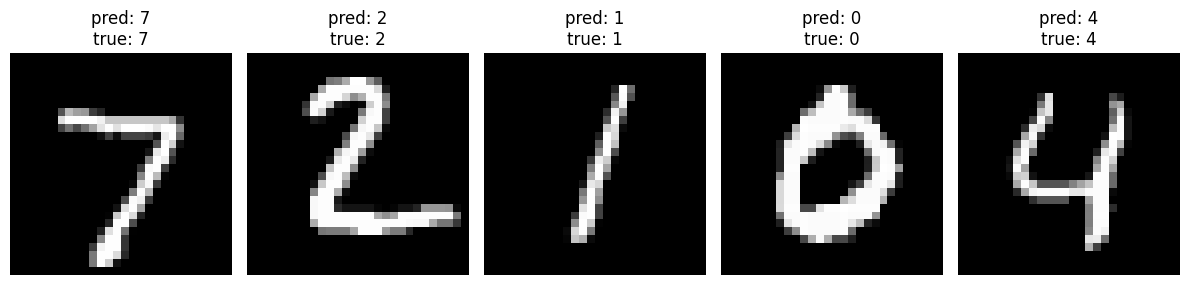

In [6]:
import matplotlib.pyplot as plt

# Виберемо модель для інференсу
inference_model = model_gpu if (model_gpu is not None) else model_cpu
inference_device = device_gpu if (model_gpu is not None) else device_cpu

inference_model.to(inference_device)
inference_model.eval()

# Беремо один batch із test_loader
images, labels = next(iter(test_loader))
images, labels = images.to(inference_device), labels.to(inference_device)

with torch.no_grad():
    outputs = inference_model(images)
    probs = F.softmax(outputs, dim=1)
    preds = probs.argmax(dim=1)

# Візуалізуємо перші 5
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img = images[i].cpu().squeeze()  # (1,28,28) -> (28,28)
    axes[i].imshow(img, cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"pred: {preds[i].item()}\ntrue: {labels[i].item()}")

plt.tight_layout()
plt.show()

## 9. Побудуйте матрицю плутанини, порівнюючи передбачення вашої моделі з істинними мітками.

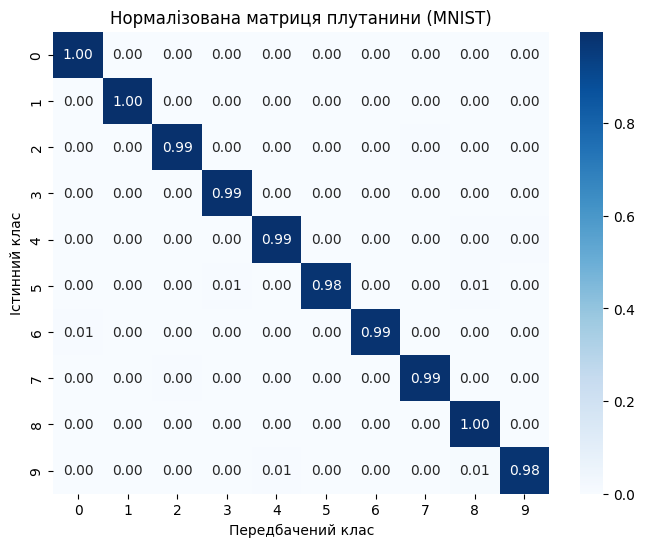

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

inference_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(inference_device), labels.to(inference_device)

        outputs = inference_model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=list(range(10)),
            yticklabels=list(range(10)))
plt.xlabel("Передбачений клас")
plt.ylabel("Істинний клас")
plt.title("Нормалізована матриця плутанини (MNIST)")
plt.show()

## 10. Виведіть принаймні 9 прикладів, де модель помиляється, разом з тим, якою мала бути мітка зображення.
* Після візуалізації цих прогнозів, як ви думаєте, це більше помилка моделювання чи помилка даних?
* Тобто, чи може модель працювати краще, чи мітки даних занадто близькі одна до одної, що навіть людина не може чітко розрізнити що це за цифра?

Знайшли 9 помилкових прикладів


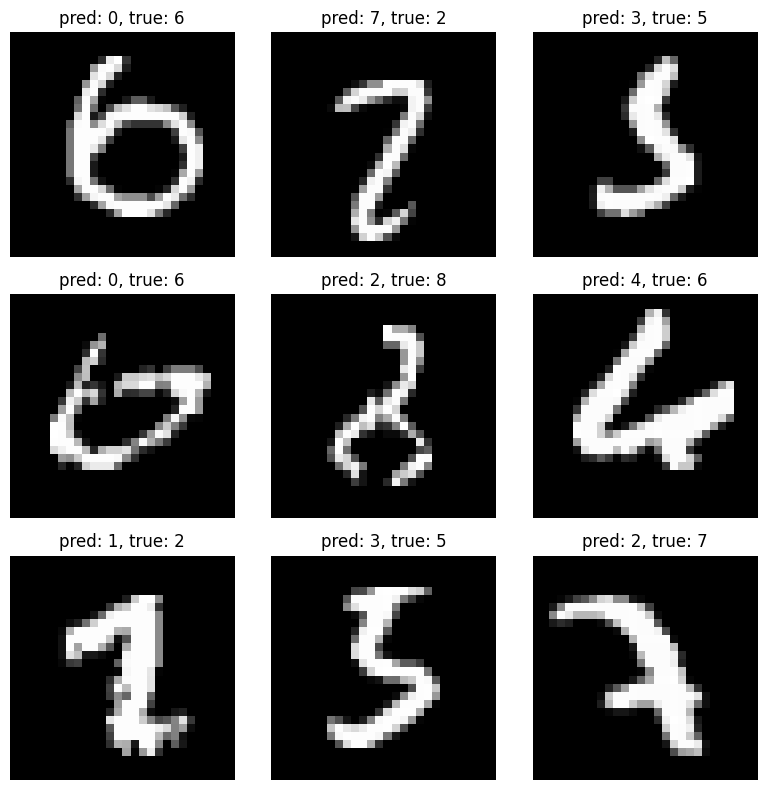

In [8]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Візьмемо модель, з якою ти працювала вище
inference_model = inference_model   # якщо ти назвала її інакше – підстав свою змінну
inference_device = inference_device # або просто device, який ти використовуєш

inference_model.to(inference_device)
inference_model.eval()

wrong_images = []
wrong_true = []
wrong_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(inference_device), labels.to(inference_device)

        outputs = inference_model(images)
        probs = F.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        mismatch = preds != labels
        if mismatch.any():
            idxs = torch.where(mismatch)[0]
            for idx in idxs:
                wrong_images.append(images[idx].cpu())
                wrong_true.append(labels[idx].item())
                wrong_pred.append(preds[idx].item())
                if len(wrong_images) >= 9:
                    break
        if len(wrong_images) >= 9:
            break

print(f"Знайшли {len(wrong_images)} помилкових прикладів")

# Візуалізуємо перші 9
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = wrong_images[i].squeeze()   # (1,28,28) -> (28,28)
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    ax.set_title(f"pred: {wrong_pred[i]}, true: {wrong_true[i]}")
plt.tight_layout()
plt.show()

## 11. Створіть випадковий тензор форми `[1, 3, 64, 64]` і пропустіть його через шар `nn.Conv2d()` з різними налаштуваннями гіперпараметрів (ви можете вибрати будь-які налаштування), що ви помічаєте, якщо параметр `kernel_size` збільшується або зменшується?

In [9]:
import torch
import torch.nn as nn

# Випадковий тензор: batch=1, channels=3, height=64, width=64
x = torch.randn(1, 3, 64, 64)
print("Вхідний тензор:", x.shape)

# Кілька варіантів Conv2d з різними kernel_size (та padding для порівняння)
convs = [
    ("k=3, padding=0", nn.Conv2d(3, 8, kernel_size=3, padding=0)),
    ("k=5, padding=0", nn.Conv2d(3, 8, kernel_size=5, padding=0)),
    ("k=7, padding=0", nn.Conv2d(3, 8, kernel_size=7, padding=0)),
    ("k=3, padding=1", nn.Conv2d(3, 8, kernel_size=3, padding=1)),
    ("k=5, padding=2", nn.Conv2d(3, 8, kernel_size=5, padding=2)),
]

for name, conv in convs:
    y = conv(x)
    print(f"{name} -> output shape: {y.shape}")

Вхідний тензор: torch.Size([1, 3, 64, 64])
k=3, padding=0 -> output shape: torch.Size([1, 8, 62, 62])
k=5, padding=0 -> output shape: torch.Size([1, 8, 60, 60])
k=7, padding=0 -> output shape: torch.Size([1, 8, 58, 58])
k=3, padding=1 -> output shape: torch.Size([1, 8, 64, 64])
k=5, padding=2 -> output shape: torch.Size([1, 8, 64, 64])
